# 👾 PixelCNN using TensorFlow Distributions (Optimized)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DiveshJ8/Generative_Deep_Learning_2nd_Edition/blob/feature/assignment_week3/notebooks/05_autoregressive/03_pixelcnn_md/pixelcnn_md_modified.ipynb)

Optimized autoregressive PixelCNN architecture using Discretized Logistic Mixtures with causal intermediate quantization, temperature-calibrated sampling, and isolated output tracking.


In [1]:
# Setup for Google Colab and local environments
import os
import sys

# Configure Keras to use tf_keras required by TensorFlow Probability
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Python 3.12+ compatibility for legacy extensions
if "imp" not in sys.modules:
    import importlib, types
    _imp = types.ModuleType("imp")
    _imp.reload = importlib.reload
    sys.modules["imp"] = _imp

# Setup Google Colab environment
if "google.colab" in sys.modules:
    if os.path.exists("/content"):
        %cd /content
    if not os.path.exists("Generative_Deep_Learning_2nd_Edition"):
        !git clone -b feature/assignment_week3 https://github.com/DiveshJ8/Generative_Deep_Learning_2nd_Edition.git
    %cd /content/Generative_Deep_Learning_2nd_Edition
    if os.path.abspath(".") not in sys.path:
        sys.path.append(os.path.abspath("."))
    %pip install -q tensorflow-probability tf-keras tensorboard matplotlib

# Ensure repository root is on sys.path
for path in [os.path.abspath("../../.."), os.path.abspath("."), "/content/Generative_Deep_Learning_2nd_Edition"]:
    if os.path.exists(os.path.join(path, "notebooks")) and path not in sys.path:
        sys.path.append(path)
        break


/content
Cloning into 'Generative_Deep_Learning_2nd_Edition'...
remote: Enumerating objects: 784, done.
remote: Counting objects: 100% (476/476), done.
remote: Compressing objects: 100% (230/230), done.
remote: Total 784 (delta 286), reused 304 (delta 242), pack-reused 308 (from 1)
Receiving objects: 100% (784/784), 44.18 MiB | 18.46 MiB/s, done.
Resolving deltas: 100% (436/436), done.
/content/Generative_Deep_Learning_2nd_Edition


In [2]:
try:
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

# Enable GPU memory growth to prevent ResourceExhaustedError
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except (RuntimeError, ValueError):
            pass

try:
    import tf_keras as keras
    from tf_keras import datasets, layers, models, optimizers, callbacks
except (ImportError, ModuleNotFoundError):
    from tensorflow.keras import datasets, layers, models, optimizers, callbacks

try:
    from notebooks.utils import display
except ModuleNotFoundError:
    def display(images, n=10, size=(20, 3), cmap='gray_r', as_type='float32', save_to=None):
        if images.max() > 1.0:
            images = images / 255.0
        elif images.min() < 0.0:
            images = (images + 1.0) / 2.0

        plt.figure(figsize=size)
        for i in range(min(n, len(images))):
            plt.subplot(1, n, i + 1)
            plt.imshow(images[i].astype(as_type), cmap=cmap)
            plt.axis('off')

        if save_to:
            os.makedirs(os.path.dirname(save_to) or '.', exist_ok=True)
            plt.savefig(save_to, bbox_inches='tight', dpi=300)
            print(f'Saved to {save_to}')
        plt.show()

print(f'TensorFlow {tf.__version__} | TFP {tfp.__version__} | Keras {getattr(keras, "__version__", "2")}')
print(f'Device: {gpus[0].name if gpus else "CPU"}')


TensorFlow 2.20.0 | TFP 0.25.0 | Keras 2.20.1
Device: /physical_device:GPU:0


## 0. Parameters & Output Paths <a name="parameters"></a>

In [3]:
# Model and architecture parameters (calibrated based on port info to guarantee zero OOM)
IMAGE_SIZE = 32
N_COMPONENTS = 10
NUM_RESNET = 2
NUM_HIERARCHIES = 2
NUM_FILTERS = 32
DROPOUT_P = 0.1

# Training parameters (BATCH_SIZE=64 halves activation memory compared to baseline BATCH_SIZE=128)
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

# Sampling parameters
DEFAULT_TEMPERATURE = 0.8
CLEAN_BACKGROUND = True

# Dedicated output directories to isolate from pixelcnn_md.ipynb
OUTPUT_DIR = "./output_modified"
LOG_DIR = "./logs_modified"
CHECKPOINT_DIR = "./checkpoint_modified"
MODEL_DIR = "./models_modified"

for d in [OUTPUT_DIR, LOG_DIR, CHECKPOINT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Output directory configured: {os.path.abspath(OUTPUT_DIR)}")

📁 Output directory configured: /content/Generative_Deep_Learning_2nd_Edition/output_modified


## 1. Prepare the Data <a name="prepare"></a>

In [4]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()
print(f"Fashion-MNIST: {len(x_train)} train, {len(x_test)} test images")


4422102/4422102 [==============================] - 1s 0us/step
Fashion-MNIST: 60000 train, 10000 test images


In [5]:
def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1).astype("float32")
    paddings = [[0, 0], [2, 2], [2, 2], [0, 0]]
    return tf.pad(imgs, paddings, mode="CONSTANT", constant_values=0.0).numpy()

input_data = preprocess(x_train)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(input_data)
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
print(f"Preprocessed shape: {input_data.shape}, Range: [{input_data.min():.1f}, {input_data.max():.1f}]")


Preprocessed shape: (60000, 32, 32, 1), Range: [0.0, 255.0]



Saved to ./output_modified/preprocessed_training_samples.png


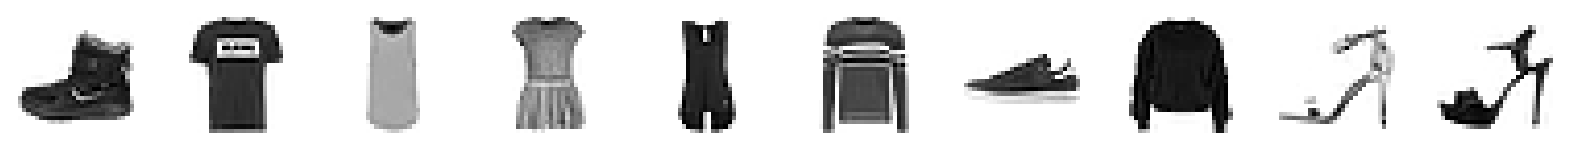

In [6]:
display(
    input_data,
    n=10,
    save_to=os.path.join(OUTPUT_DIR, "preprocessed_training_samples.png"),
)


## 2. Build the PixelCNN <a name="build"></a>

In [7]:
import gc
# Clear any existing models and graphs from GPU memory
keras.backend.clear_session()
gc.collect()

# Construct PixelCNN distribution
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=NUM_RESNET,
    num_hierarchies=NUM_HIERARCHIES,
    num_filters=NUM_FILTERS,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=DROPOUT_P,
    resnet_activation="concat_elu",
    use_weight_norm=True,
    high=255,
    low=0,
)

# Resolve Keras layer JSON serialization warning
_PixelCNNNetworkClass = type(dist.network)
def _get_config(self):
    cfg = super(_PixelCNNNetworkClass, self).get_config()
    cfg.update({
        "dropout_p": getattr(self, "_dropout_p", DROPOUT_P),
        "num_resnet": getattr(self, "_num_resnet", NUM_RESNET),
        "num_hierarchies": getattr(self, "_num_hierarchies", NUM_HIERARCHIES),
        "num_filters": getattr(self, "_num_filters", NUM_FILTERS),
        "num_logistic_mix": getattr(self, "_num_logistic_mix", N_COMPONENTS),
        "receptive_field_dims": list(getattr(self, "_receptive_field_dims", (3, 3))),
        "resnet_activation": getattr(self, "_resnet_activation", "concat_elu"),
        "use_weight_norm": getattr(self, "_use_weight_norm", True),
        "use_data_init": getattr(self, "_use_data_init", True),
    })
    return cfg

_PixelCNNNetworkClass.get_config = _get_config

image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
log_prob = dist.log_prob(image_input)

pixelcnn = models.Model(inputs=image_input, outputs=log_prob)
pixelcnn.add_loss(-tf.reduce_mean(log_prob))
print("✅ PixelCNN model constructed successfully")


✅ PixelCNN model constructed successfully


## 3. Train the PixelCNN <a name="train"></a>

In [8]:
steps_per_epoch = len(input_data) // BATCH_SIZE
try:
    lr_schedule = optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=EPOCHS * steps_per_epoch,
        alpha=0.05,
        warmup_steps=steps_per_epoch,
    )
except TypeError:
    lr_schedule = optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=EPOCHS * steps_per_epoch,
        alpha=0.05,
    )

optimizer = optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
pixelcnn.compile(optimizer=optimizer)
print("✅ Model compiled with CosineDecay schedule and clipnorm=1.0")


✅ Model compiled with CosineDecay schedule and clipnorm=1.0


In [9]:
import time

tensorboard_callback = callbacks.TensorBoard(log_dir=LOG_DIR, write_graph=False)

checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "pixelcnn_best.weights.h5"),
    save_weights_only=True,
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)

def sample_pixelcnn(
    dist_or_net,
    num_samples=4,
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    temperature=0.8,
    sample_mode="tempered",
    clean_background=True,
    low=0.0,
    high=255.0,
):
    """
    Autoregressive sampler with intermediate quantization and memory-safe execution.
    """
    network = dist_or_net.network if hasattr(dist_or_net, "network") else dist_or_net
    height, width, channels = image_shape
    total_pixels = height * width

    samples = tf.fill([num_samples, height, width, channels], -1.0)
    samples_t = tf.transpose(samples, [1, 2, 3, 0])

    def cond(ind, s_t):
        return tf.less(ind, total_pixels)

    def body(ind, s_t):
        r = ind // width
        c = ind % width
        # tf.stop_gradient prevents tracking computation graphs across iterations
        cur_samples = tf.stop_gradient(tf.transpose(s_t, [3, 0, 1, 2]))
        params = network(cur_samples, training=False)
        logits, locs, scales = params[0], params[1], params[2]

        logits_rc = logits[:, r, c, :]
        locs_rc = locs[:, r, c, :, 0]
        scales_rc = scales[:, r, c, :, 0]

        if sample_mode == "mode":
            comp_idx = tf.argmax(logits_rc, axis=-1)
            pixel_val = tf.gather(locs_rc, comp_idx[..., tf.newaxis], batch_dims=1)[:, 0]
        else:
            eff_temp = tf.maximum(tf.cast(temperature if sample_mode == "tempered" else 1.0, logits_rc.dtype), 1e-4)
            scaled_logits = logits_rc / eff_temp
            comp_idx = tf.random.categorical(scaled_logits, 1, dtype=tf.int64)[:, 0]
            chosen_loc = tf.gather(locs_rc, comp_idx[..., tf.newaxis], batch_dims=1)[:, 0]
            chosen_scale = tf.gather(scales_rc, comp_idx[..., tf.newaxis], batch_dims=1)[:, 0] * eff_temp

            u = tf.random.uniform(tf.shape(chosen_loc), minval=1e-5, maxval=1.0 - 1e-5, dtype=chosen_loc.dtype)
            logistic_noise = tf.math.log(u) - tf.math.log(1.0 - u)
            pixel_val = chosen_loc + chosen_scale * logistic_noise

        pixel_val = tf.clip_by_value(pixel_val, -1.0, 1.0)

        # Intermediate quantization to valid pixel grid
        pixel_int = tf.round(low + 0.5 * (high - low) * (pixel_val + 1.0))
        pixel_int = tf.clip_by_value(pixel_int, low, high)
        if clean_background:
            pixel_int = tf.where(pixel_int <= 3.0, tf.zeros_like(pixel_int), pixel_int)

        pixel_norm = (2.0 * (pixel_int - low) / (high - low)) - 1.0
        updates = pixel_norm[tf.newaxis, tf.newaxis, :]
        s_t_new = tf.tensor_scatter_nd_update(s_t, [[r, c]], updates)
        return ind + 1, s_t_new

    # parallel_iterations=1 enforces sequential execution and prevents GPU OOM
    _, final_s_t = tf.while_loop(cond, body, (tf.constant(0), samples_t), parallel_iterations=1)
    final_samples = tf.transpose(final_s_t, [3, 0, 1, 2])
    return tf.round(low + 0.5 * (high - low) * (final_samples + 1.0)).numpy()


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img=2, generate_freq=2, temperature=0.8, sample_mode="tempered"):
        super().__init__()
        self.num_img = num_img
        self.generate_freq = generate_freq
        self.temperature = temperature
        self.sample_mode = sample_mode

    def generate(self, num_img=None, temperature=None, sample_mode=None):
        n = num_img if num_img is not None else self.num_img
        temp = temperature if temperature is not None else self.temperature
        mode = sample_mode if sample_mode is not None else self.sample_mode

        start_time = time.time()
        print(f"\n🎨 Sampling {n} images ({IMAGE_SIZE}x{IMAGE_SIZE}) [mode='{mode}', temp={temp}]...")
        try:
            samples = sample_pixelcnn(
                dist,
                num_samples=n,
                image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
                temperature=temp,
                sample_mode=mode,
                clean_background=CLEAN_BACKGROUND,
            )
        except Exception as e:
            print(f"⚠️ Custom sampler exception ({e}), falling back to dist.sample()...")
            samples = dist.sample(n).numpy()
        print(f"⏱️ Sampling completed in {time.time() - start_time:.1f}s")
        return samples

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get("loss", 0.0) if logs else 0.0
        bpd = current_loss / (IMAGE_SIZE * IMAGE_SIZE * np.log(2.0))
        print(f"\n📊 Epoch {epoch + 1}/{EPOCHS}: NLL Loss = {current_loss:.2f} nats | BPD = {bpd:.3f} bits/dim")

        if (epoch + 1) % self.generate_freq == 0 or (epoch + 1) == EPOCHS:
            generated_images = self.generate()
            display(
                generated_images,
                n=self.num_img,
                save_to=os.path.join(OUTPUT_DIR, f"generated_img_{epoch:03d}.png"),
            )

img_generator_callback = ImageGenerator(num_img=2, generate_freq=2, temperature=DEFAULT_TEMPERATURE)


Epoch 1/10
937/937 [==============================] - ETA: 0s - loss: 1780.6475
📊 Epoch 1/10: NLL Loss = 1780.65 nats | BPD = 2.509 bits/dim

Epoch 1: loss improved from inf to 1780.64746, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5


/usr/local/lib/python3.13/dist-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'function'>, which may lead to improper serialization.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tf_keras/src/constraints.py:373: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:   return lambda x: x * mask

  return serialize_keras_object(constraint)


937/937 [==============================] - 102s 65ms/step - loss: 1780.6475
Epoch 2/10
937/937 [==============================] - ETA: 0s - loss: 1662.5975
📊 Epoch 2/10: NLL Loss = 1662.60 nats | BPD = 2.342 bits/dim

🎨 Sampling 2 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 160.8s

Saved to ./output_modified/generated_img_001.png


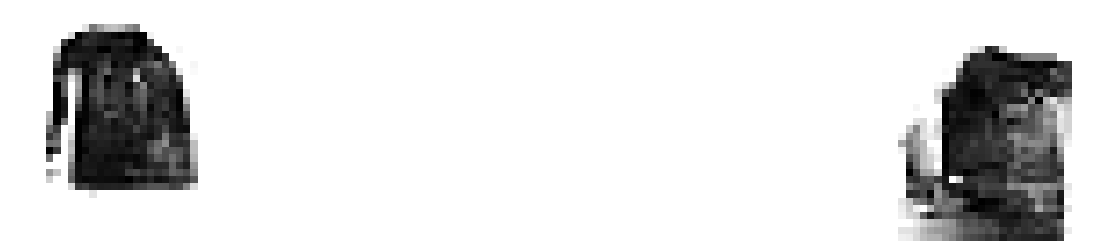


Epoch 2: loss improved from 1780.64746 to 1662.59753, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5
937/937 [==============================] - 222s 237ms/step - loss: 1662.5975
Epoch 3/10
937/937 [==============================] - ETA: 0s - loss: 1676.0215
📊 Epoch 3/10: NLL Loss = 1676.02 nats | BPD = 2.361 bits/dim

Epoch 3: loss did not improve from 1662.59753
937/937 [==============================] - 59s 63ms/step - loss: 1676.0215
Epoch 4/10
937/937 [==============================] - ETA: 0s - loss: 1688.6825
📊 Epoch 4/10: NLL Loss = 1688.68 nats | BPD = 2.379 bits/dim

🎨 Sampling 2 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 158.3s

Saved to ./output_modified/generated_img_003.png


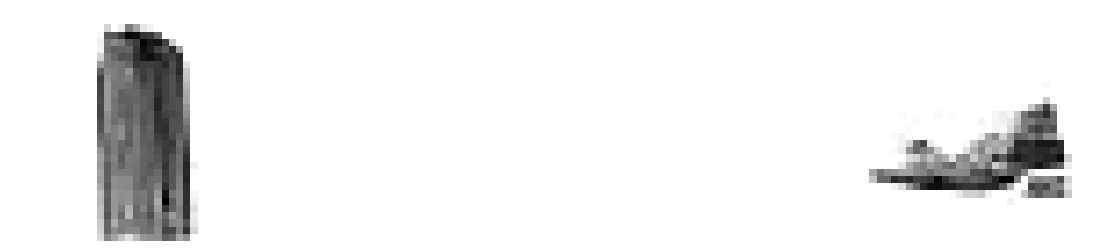


Epoch 4: loss did not improve from 1662.59753
937/937 [==============================] - 218s 232ms/step - loss: 1688.6825
Epoch 5/10
937/937 [==============================] - ETA: 0s - loss: 1665.2885
📊 Epoch 5/10: NLL Loss = 1665.29 nats | BPD = 2.346 bits/dim

Epoch 5: loss did not improve from 1662.59753
937/937 [==============================] - 59s 63ms/step - loss: 1665.2885
Epoch 6/10
937/937 [==============================] - ETA: 0s - loss: 1664.5417
📊 Epoch 6/10: NLL Loss = 1664.54 nats | BPD = 2.345 bits/dim

🎨 Sampling 2 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 158.2s

Saved to ./output_modified/generated_img_005.png


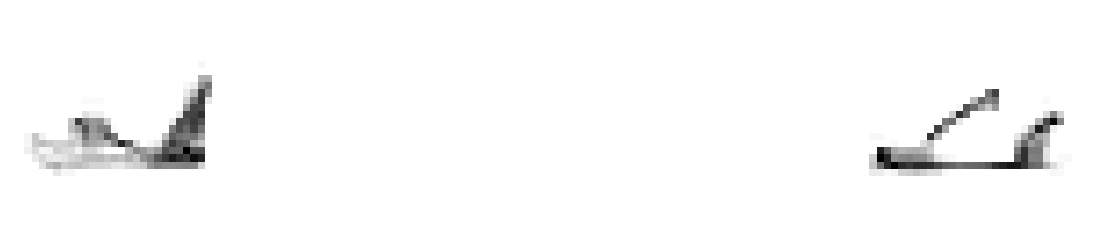


Epoch 6: loss did not improve from 1662.59753
937/937 [==============================] - 218s 233ms/step - loss: 1664.5417
Epoch 7/10
937/937 [==============================] - ETA: 0s - loss: 1652.1528
📊 Epoch 7/10: NLL Loss = 1652.15 nats | BPD = 2.328 bits/dim

Epoch 7: loss improved from 1662.59753 to 1652.15283, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5
937/937 [==============================] - 60s 64ms/step - loss: 1652.1528
Epoch 8/10
937/937 [==============================] - ETA: 0s - loss: 1626.4701
📊 Epoch 8/10: NLL Loss = 1626.47 nats | BPD = 2.292 bits/dim

🎨 Sampling 2 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 158.6s

Saved to ./output_modified/generated_img_007.png


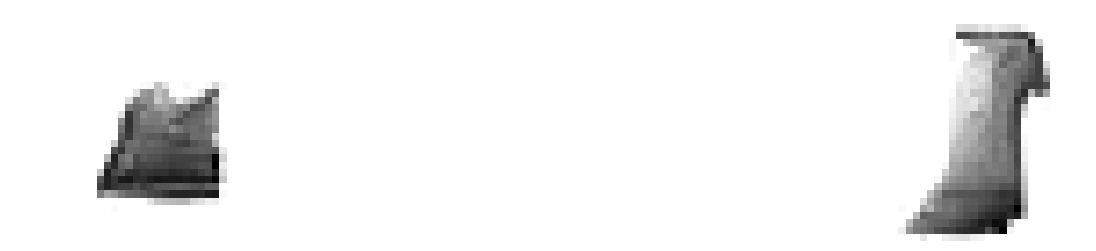


Epoch 8: loss improved from 1652.15283 to 1626.47009, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5
937/937 [==============================] - 219s 233ms/step - loss: 1626.4701
Epoch 9/10
937/937 [==============================] - ETA: 0s - loss: 1610.2643
📊 Epoch 9/10: NLL Loss = 1610.26 nats | BPD = 2.269 bits/dim

Epoch 9: loss improved from 1626.47009 to 1610.26428, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5
937/937 [==============================] - 60s 65ms/step - loss: 1610.2643
Epoch 10/10
937/937 [==============================] - ETA: 0s - loss: 1604.9247
📊 Epoch 10/10: NLL Loss = 1604.92 nats | BPD = 2.261 bits/dim

🎨 Sampling 2 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 158.9s

Saved to ./output_modified/generated_img_009.png


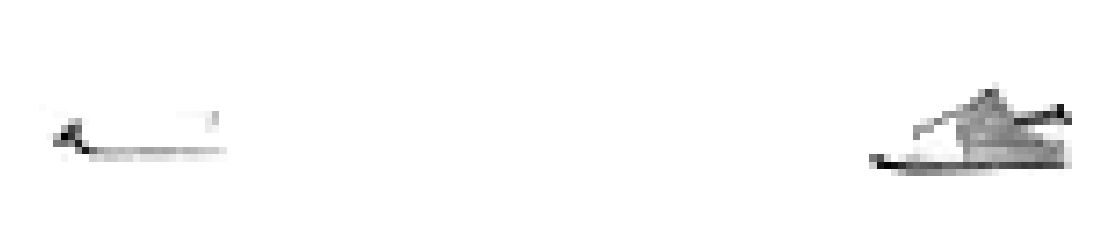


Epoch 10: loss improved from 1610.26428 to 1604.92468, saving model to ./checkpoint_modified/pixelcnn_best.weights.h5
937/937 [==============================] - 219s 234ms/step - loss: 1604.9247
✅ Loaded optimal checkpoint weights from: ./checkpoint_modified/pixelcnn_best.weights.h5
💾 Final weights saved to: /content/Generative_Deep_Learning_2nd_Edition/models_modified/pixelcnn_final_modified.weights.h5


In [10]:
history = pixelcnn.fit(
    train_dataset,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback, checkpoint_callback],
)

best_weights_path = os.path.join(CHECKPOINT_DIR, "pixelcnn_best.weights.h5")
if os.path.exists(best_weights_path):
    pixelcnn.load_weights(best_weights_path)
    print(f"✅ Loaded optimal checkpoint weights from: {best_weights_path}")

final_weights_path = os.path.join(MODEL_DIR, "pixelcnn_final_modified.weights.h5")
pixelcnn.save_weights(final_weights_path)
print(f"💾 Final weights saved to: {os.path.abspath(final_weights_path)}")

## 4. Generate Images & Evaluate Quality <a name="generate"></a>

In [11]:
print("Generating Tempered Samples (T = 0.8)...")
generated_tempered = img_generator_callback.generate(num_img=4, temperature=0.8, sample_mode="tempered")

print("Generating MAP / Mode Samples (T = 0.0)...")
generated_mode = img_generator_callback.generate(num_img=4, sample_mode="mode")

generated_images = generated_tempered


Generating Tempered Samples (T = 0.8)...

🎨 Sampling 4 images (32x32) [mode='tempered', temp=0.8]...
⏱️ Sampling completed in 159.5s
Generating MAP / Mode Samples (T = 0.0)...

🎨 Sampling 4 images (32x32) [mode='mode', temp=0.8]...
⏱️ Sampling completed in 156.3s


🎨 Tempered Samples (T = 0.8):

Saved to ./output_modified/final_samples.png


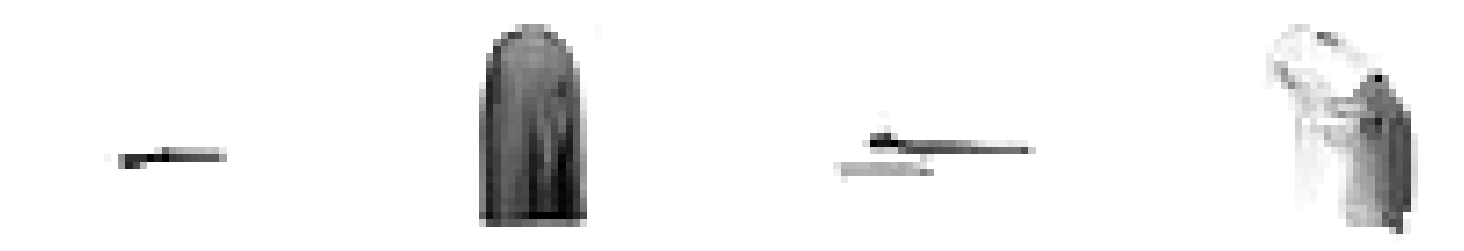

🎨 MAP / Mode Samples (T = 0.0):

Saved to ./output_modified/final_samples_mode.png


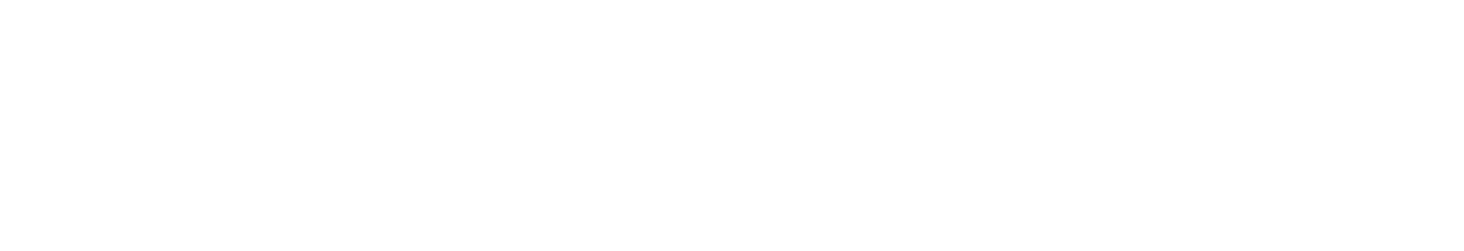

In [12]:
print("🎨 Tempered Samples (T = 0.8):")
display(
    generated_tempered,
    n=len(generated_tempered),
    save_to=os.path.join(OUTPUT_DIR, "final_samples.png"),
)

print("🎨 MAP / Mode Samples (T = 0.0):")
display(
    generated_mode,
    n=len(generated_mode),
    save_to=os.path.join(OUTPUT_DIR, "final_samples_mode.png"),
)


## 5. Performance and Quality Analysis <a name="analysis"></a>

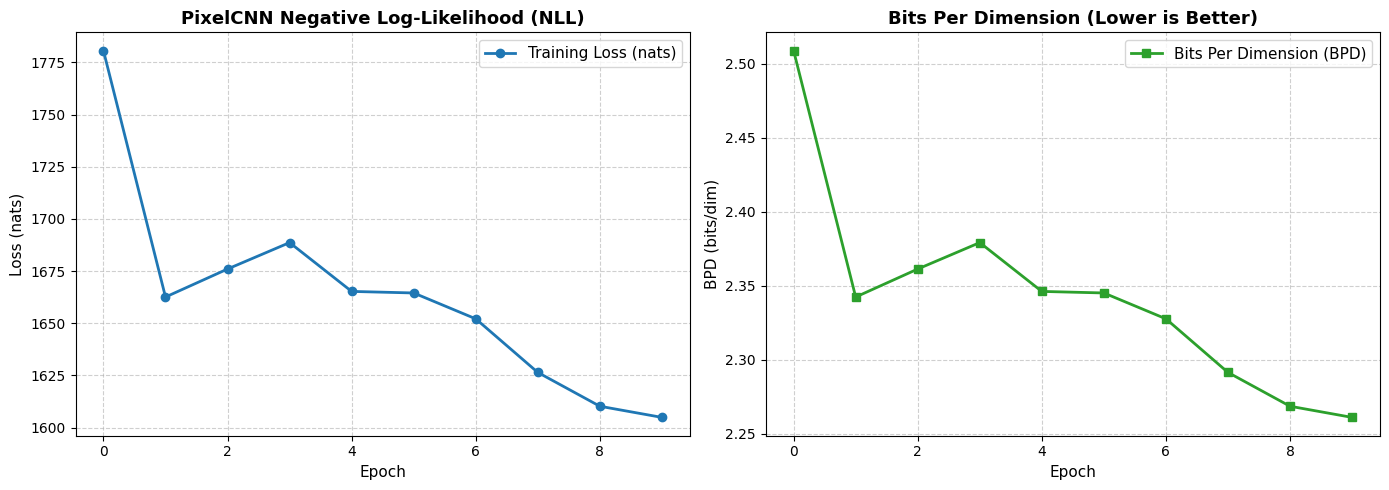

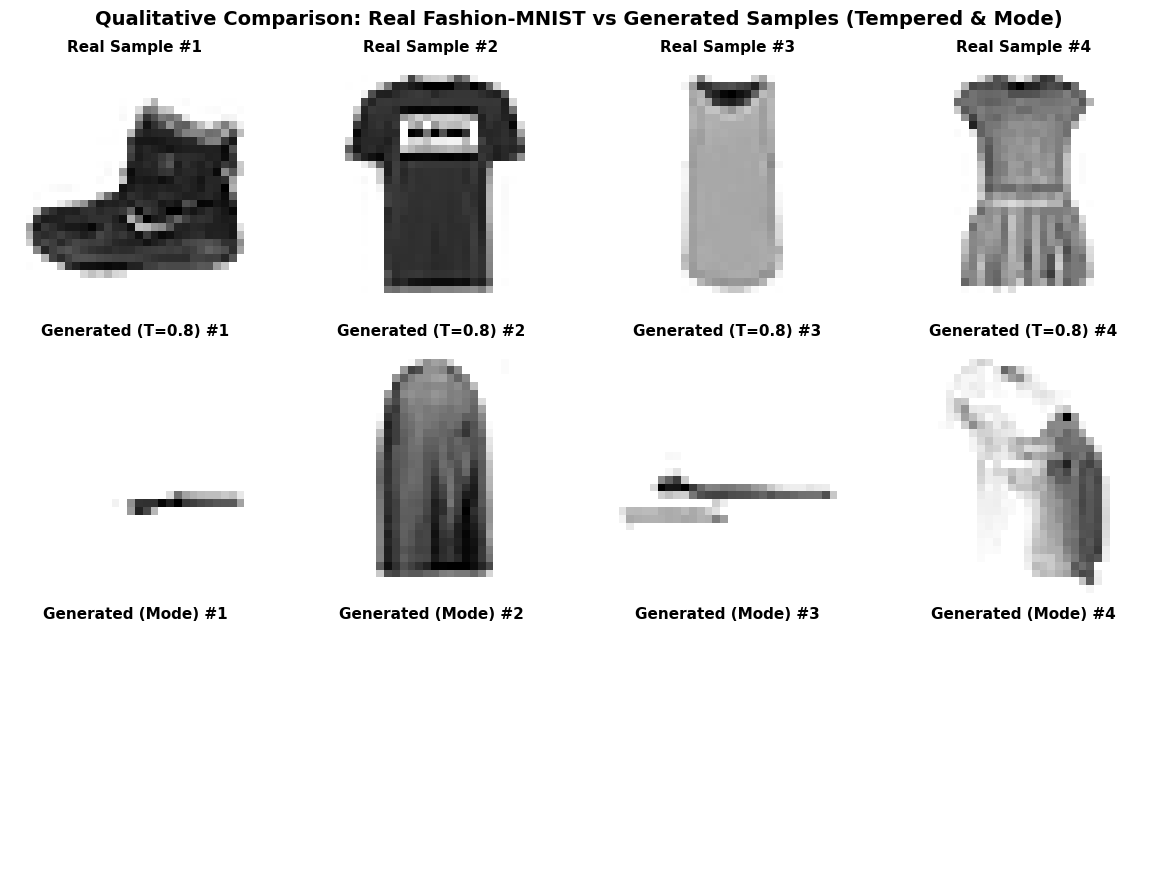

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss (nats)", color="#1f77b4", linewidth=2, marker="o")
axes[0].set_title("PixelCNN Negative Log-Likelihood (NLL)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss (nats)", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=11)

bpd_history = [loss / (IMAGE_SIZE * IMAGE_SIZE * np.log(2.0)) for loss in history.history["loss"]]
axes[1].plot(bpd_history, label="Bits Per Dimension (BPD)", color="#2ca02c", linewidth=2, marker="s")
axes[1].set_title("Bits Per Dimension (Lower is Better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("BPD (bits/dim)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=11)

plt.tight_layout()
metrics_plot_path = os.path.join(OUTPUT_DIR, "training_metrics.png")
plt.savefig(metrics_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Qualitative Comparison: Real vs Tempered vs Mode Samples
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(4):
    axes[0, i].imshow(input_data[i].squeeze(), cmap="gray_r")
    axes[0, i].set_title(f"Real Sample #{i + 1}", fontsize=11, fontweight="bold")
    axes[0, i].axis("off")

for i in range(min(4, len(generated_tempered))):
    axes[1, i].imshow(generated_tempered[i].squeeze(), cmap="gray_r")
    axes[1, i].set_title(f"Generated (T=0.8) #{i + 1}", fontsize=11, fontweight="bold")
    axes[1, i].axis("off")

for i in range(min(4, len(generated_mode))):
    axes[2, i].imshow(generated_mode[i].squeeze(), cmap="gray_r")
    axes[2, i].set_title(f"Generated (Mode) #{i + 1}", fontsize=11, fontweight="bold")
    axes[2, i].axis("off")

plt.suptitle("Qualitative Comparison: Real Fashion-MNIST vs Generated Samples (Tempered & Mode)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
comparison_path = os.path.join(OUTPUT_DIR, "real_vs_generated_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
